In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
orders = pd.read_csv("olist_orders_dataset.csv")
items = pd.read_csv("olist_order_items_dataset.csv")
products = pd.read_csv("olist_products_dataset.csv")
customers = pd.read_csv("olist_customers_dataset.csv")
reviews = pd.read_csv("olist_order_reviews_dataset.csv")
payments = pd.read_csv("olist_order_payments_dataset.csv")

In [4]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,02-10-2017 10:56,02-10-2017 11:07,04-10-2017 19:55,10-10-2017 21:25,18-10-2017 00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,24-07-2018 20:41,26-07-2018 03:24,26-07-2018 14:31,07-08-2018 15:27,13-08-2018 00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,08-08-2018 08:38,08-08-2018 08:55,08-08-2018 13:50,17-08-2018 18:06,04-09-2018 00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,18-11-2017 19:28,18-11-2017 19:45,22-11-2017 13:39,02-12-2017 00:28,15-12-2017 00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,13-02-2018 21:18,13-02-2018 22:20,14-02-2018 19:46,16-02-2018 18:17,26-02-2018 00:00


In [5]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [6]:
orders.isnull().sum()

,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,160
order_delivered_carrier_date,1783
order_delivered_customer_date,2965
order_estimated_delivery_date,0


In [7]:
orders["returned"] = orders["order_status"].apply(
    lambda x: 1 if x in ["canceled", "unavailable"] else 0
)

In [8]:
orders["returned"].value_counts()

,count
returned,
0,98207
1,1234


In [9]:
df = pd.merge(orders, customers, on="customer_id")
df = pd.merge(df, items, on="order_id")
df = pd.merge(df, products, on="product_id")

In [10]:
df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,returned,customer_unique_id,...,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,02-10-2017 10:56,02-10-2017 11:07,04-10-2017 19:55,10-10-2017 21:25,18-10-2017 00:00,0,7c396fd4830fd04220f754e42b4e5bff,...,29.99,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,24-07-2018 20:41,26-07-2018 03:24,26-07-2018 14:31,07-08-2018 15:27,13-08-2018 00:00,0,af07308b275d755c9edb36a90c618231,...,118.70,22.76,perfumaria,29.0,178.0,1.0,400.0,19.0,13.0,19.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,08-08-2018 08:38,08-08-2018 08:55,08-08-2018 13:50,17-08-2018 18:06,04-09-2018 00:00,0,3a653a41f6f9fc3d2a113cf8398680e8,...,159.90,19.22,automotivo,46.0,232.0,1.0,420.0,24.0,19.0,21.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,18-11-2017 19:28,18-11-2017 19:45,22-11-2017 13:39,02-12-2017 00:28,15-12-2017 00:00,0,7c142cf63193a1473d2e66489a9ae977,...,45.00,27.20,pet_shop,59.0,468.0,3.0,450.0,30.0,10.0,20.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,13-02-2018 21:18,13-02-2018 22:20,14-02-2018 19:46,16-02-2018 18:17,26-02-2018 00:00,0,72632f0f9dd73dfee390c9b22eb56dd6,...,19.90,8.72,papelaria,38.0,316.0,4.0,250.0,51.0,15.0,15.0


In [11]:
df.shape

(112650, 27)

In [12]:
return_rate = df["returned"].mean()*100
print("Overall Return Rate =", round(return_rate,2), "%")

Overall Return Rate = 0.49 %


In [13]:
category_return = df.groupby("product_category_name")["returned"].mean()*100
category_return = category_return.sort_values(ascending=False).head(10)
print(category_return)

product_category_name
pc_gamer                                         11.111111
portateis_cozinha_e_preparadores_de_alimentos     6.666667
dvds_blu_ray                                      3.125000
construcao_ferramentas_seguranca                  2.577320
fraldas_higiene                                   2.564103
construcao_ferramentas_jardim                     1.680672
instrumentos_musicais                             1.617647
livros_interesse_geral                            1.265823
eletrodomesticos_2                                1.260504
eletroportateis                                   1.178203
Name: returned, dtype: float64


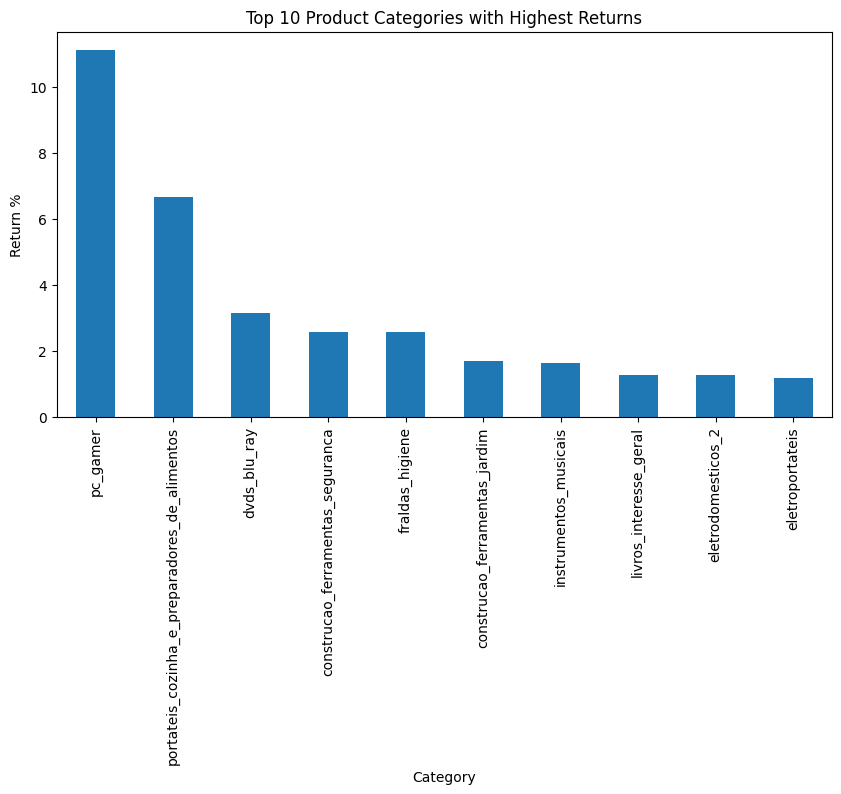

In [14]:
plt.figure(figsize=(10,5))
category_return.plot(kind="bar")
plt.title("Top 10 Product Categories with Highest Returns")
plt.xlabel("Category")
plt.ylabel("Return %")
plt.show()

In [15]:
state_return = df.groupby("customer_state")["returned"].mean()*100
state_return = state_return.sort_values(ascending=False).head(10)
print(state_return)

customer_state
RR    1.923077
SP    0.623828
PI    0.553506
MA    0.485437
RJ    0.480143
MG    0.441770
GO    0.428633
RS    0.384924
DF    0.374065
BA    0.368518
Name: returned, dtype: float64


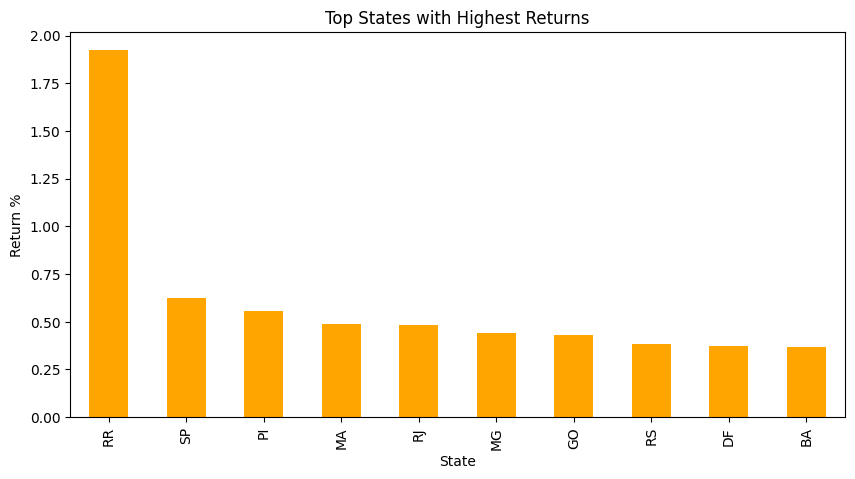

In [16]:
plt.figure(figsize=(10,5))
state_return.plot(kind="bar", color="orange")
plt.title("Top States with Highest Returns")
plt.xlabel("State")
plt.ylabel("Return %")
plt.show()

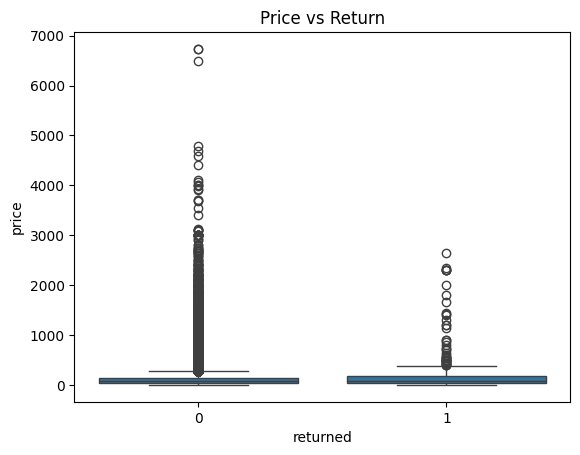

In [17]:
sns.boxplot(x="returned", y="price", data=df)
plt.title("Price vs Return")
plt.show()

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [19]:
X = df[["price","freight_value"]]
y = df["returned"]

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [21]:
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [22]:
pred = model.predict(X_test)
print("Accuracy =", accuracy_score(y_test, pred))

Accuracy = 0.9943630714602751


1. Some categories have higher returns.
2. Certain states return more products.
3. Higher freight may impact returns.
4. Model predicts returns successfully.